## 习题 1-2
载入图像 `dog.jpg`，并计算其**经济型 SVD（economy SVD）**。

计算截断 SVD 在 Frobenius 范数下的**相对重构误差**，并将其表示为秩 $r$ 的函数。将该误差平方，从而得到**缺失方差所占比例**，并同样表示为 $r$ 的函数。

也可以作图表示：

- $1-$ 重构误差，或
- $1-$ 缺失方差，

以可视化在给定秩 $r$ 下所捕获的范数或方差比例。

把这些量与**奇异值累积和**随 $r$ 变化的曲线一起画出来。

找出使重构捕获**总方差 99%** 所对应的秩 $r$。然后将其与以下两种情形对应的秩进行比较：

1. 在 Frobenius 范数意义下捕获 99%；
2. 捕获奇异值累积和的 99%。

In [1]:
from matplotlib.image import imread
import matplotlib.pyplot as plt
import numpy as np

Task1: 载入图像 `dog.jpg`，并计算其**经济型 SVD（economy SVD）**。

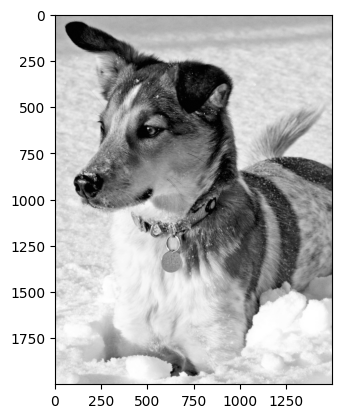

In [2]:
A = imread('../../DATA/dog.jpg')
X = np.mean(A,-1)
img = plt.imshow(X)
img.set_cmap('gray')

In [3]:
# 计算ECO SVD
U, Sigma, V_T = np.linalg.svd(X, full_matrices=False)
p = Sigma.shape[0]
r_array = np.arange(1,p+1,1)



Task2: 计算截断 SVD 在 Frobenius 范数下的**相对重构误差**，并将其表示为秩 $r$ 的函数。

In [4]:
Error_norm_rate_array = []
for r in r_array:
    U_r = U[:,:r]
    Sigma_r = Sigma[:r]
    V_T_r = V_T[:r,:]
    # 计算X_tilde
    X_tilde = U_r @ np.diag(Sigma_r) @ V_T_r
    Error = X - X_tilde
    Error_norm_rate = np.linalg.norm(Error,ord='fro')/np.linalg.norm(X,ord='fro')
    Error_norm_rate_array.append(Error_norm_rate)



Task3: 将该误差平方，从而得到**缺失方差所占比例**，并同样表示为 $r$ 的函数。作图表示：$1-$ 重构误差 和 $1-$ 缺失方差，以可视化在给定秩 $r$ 下所捕获的范数或方差比例。

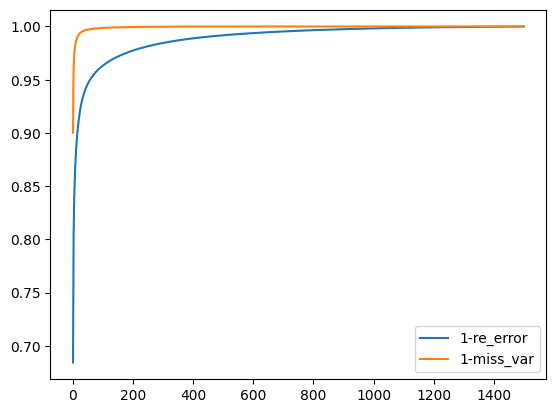

In [5]:
miss_Error_norm_rate_array_square = np.square(Error_norm_rate_array)
error_norm_rate_array = 1-np.array(Error_norm_rate_array)
plt.plot(r_array,1-np.array(Error_norm_rate_array),label='1-re_error')
plt.plot(r_array,1-miss_Error_norm_rate_array_square,label='1-miss_var')
plt.legend(loc='best')

plt.show()

Task4: 把这些量与**奇异值累积和**随 $r$ 变化的曲线一起画出来。

In [6]:
sig_value_sum_rate = []
for r in r_array:
    sig_value_sum_rate.append(np.sum(Sigma[:r])/np.sum(Sigma))
    

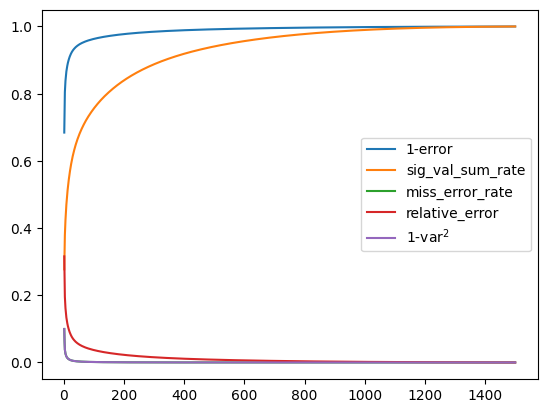

In [7]:
plt.plot(r_array,error_norm_rate_array,label='1-error')
plt.plot(r_array,sig_value_sum_rate,label='sig_val_sum_rate')
plt.plot(r_array,miss_Error_norm_rate_array_square,label='miss_error_rate')
plt.plot(r_array,Error_norm_rate_array,label='relative_error')
plt.plot(r_array,miss_Error_norm_rate_array_square,label='1-var$^2$')
plt.legend()

plt.show()

Task6: 找出使重构捕获**总方差 99%** 所对应的秩 $r$。然后将其与以下两种情形对应的秩进行比较：
1. 在 Frobenius 范数意义下捕获 99%；
2. 捕获奇异值累积和的 99%。

In [8]:
r_var99 = np.argmax(1-(miss_Error_norm_rate_array_square)>0.99) + 1
r_var99

np.int64(16)

In [9]:
# 在 Frobenius 范数意义下捕获 99%；
r_fro99 = np.argmax((error_norm_rate_array)>0.99) + 1
r_fro99

np.int64(436)

In [10]:
# 捕获奇异值累积和的 99%。
sig_value_sum_rate_array = np.array(sig_value_sum_rate)
r_sum99 = np.argmax((sig_value_sum_rate_array)>0.99) +1
r_sum99

np.int64(1006)